# Pytorch Playground

Deep learning framework aid in development and deployment of neural networks. Some of the popular frameworks are JAX, pytorch, and others. Matplotlib and numpy are other framework for visualization and numerical computation.

In [70]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Subset
from torchvision import datasets, transforms

## Tensors
However, in all the frameworks a data structure called **tensors** is used. The tensors are allocated and initialized using different functions.


In [69]:
x1 = torch.tensor([[2, 1]]) #2-d tensor
x2 = torch.tensor([[1],[2]])
C = torch.mm(x1,x2)
print(C)

tensor([[4]])


Some of the functions are in sub-libraries. e.g. torch.nn.functional.

In [71]:
import torch.nn.functional as F
x2 = torch.tensor([2, 1, -0.5])
relu_out = F.relu(x2)
print(f"ReLU: {relu_out}")

ReLU: tensor([2., 1., 0.])


**Task 1**: Use one of the functions and visualize it with matplotlib.
* zeros()
* ones()
* randn()
* eye()
* others

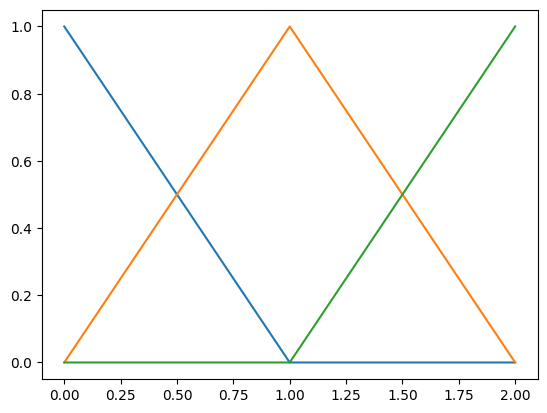

In [42]:
#TODO
import numpy as np
import matplotlib as mp

# v = np.zeros(2)
# v = np.random.randn(4)
v = np.eye(3)
plt.plot(v)

plt.show()

## Data and Dataset

Training machine learning needs large datasets. These can be images, audio, words, and others represented as tensors. **MNIST** is a data containing grayscale images of handwritten digits (0-9) with resolution of 28x28 pixels. It not only contains images but als ground truth labels.  The dataset has 60,000 training images and 10,000 test images

 The original paper in 1989 used only 7291 training images and 2007 test images of 16x16 pixels.  The images in MNIST Dataset are resized from 28x28 to 16x16. Furthermore, the pixels are scaled from (0,255) to (0,1)

In [45]:

transform = transforms.Compose([
    transforms.Resize((16, 16)),
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)
train_subset_size = 7291
test_subset_size = 2007
train_subset = torch.utils.data.Subset(train_dataset, range(train_subset_size))
test_subset = torch.utils.data.Subset(test_dataset, range(test_subset_size))

Shape is a important concept in deep learning, as it indicates the organization of data, MNIST images in PyTorch are always stored as $C \times H \times W$ (Channels, Height, Width). The image pixel in MNIST is grayscale therefore, the number of channels is 1.



**Task 2** Find out the shape in an MNIST image. Visualize a sample image with its label using matplotlib.

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])
torch.Size([1, 16, 16])


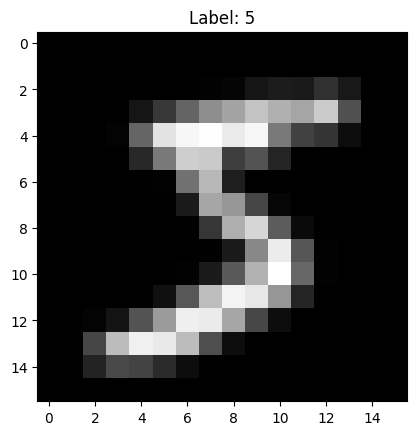

In [55]:
#TODO
print(train_dataset.data.shape)
print(test_dataset.data.shape)

image, label = train_dataset[0]
print(image.shape)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")

plt.show()


## Data preprocesing

Data preprocessing plays a major role in Machine Learning training.

['X', 'Y']
(2007, 1, 16, 16)
(2007, 10)
--- X ---
  Shape:    (2007, 1, 16, 16)
  Dtype:    float32
  Min:      -1.0
  Max:      1.0
  Mean:     -0.7579
  Std:      0.5013

--- Y ---
  Shape:    (2007, 10)
  Dtype:    float32
  Min:      -1.0
  Max:      1.0
  Mean:     -0.8000
  Std:      0.6000

  Class -1.0: 349108 samples
  Class -0.9921568632125854: 7240 samples
  Class -0.9843137264251709: 4380 samples
  Class -0.9764705896377563: 3494 samples
  Class -0.9686274528503418: 2992 samples
  Class -0.9607843160629272: 2585 samples
  Class -0.9529411792755127: 2429 samples
  Class -0.9450980424880981: 2118 samples
  Class -0.9372549057006836: 2009 samples
  Class -0.929411768913269: 1772 samples
  Class -0.9215686321258545: 1606 samples
  Class -0.9137254953384399: 1557 samples
  Class -0.9058823585510254: 1350 samples
  Class -0.8980392217636108: 1329 samples
  Class -0.8901960849761963: 1258 samples
  Class -0.8823529481887817: 1174 samples
  Class -0.8745098114013672: 1183 samples
 

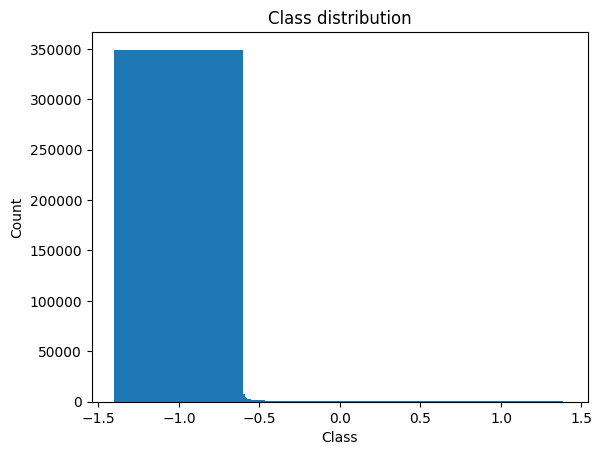

In [68]:
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=len(train_subset), shuffle=True)
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=len(test_subset), shuffle=True)
x_train, y_train = next(iter(train_loader))
x_test, y_test = next(iter(test_loader))
dataset_dict = {
    'train': (x_train, y_train, 7291),
    'test': (x_test, y_test, 2007)
}

for split_name, (x_raw, y_raw, n) in dataset_dict.items():
    x_processed = (x_raw[:n] * 2.0) - 1.0
    y_processed = F.one_hot(y_raw[:n], num_classes=10).float()
    y_processed = (y_processed * 2.0) - 1.0
    x_final = x_processed.numpy().astype(np.float32)
    y_final = y_processed.numpy().astype(np.float32)
    filename = f"./data/{split_name}1989.npz"
    np.savez(filename, X=x_final, Y=y_final)

data = np.load('./data/test1989.npz')
print(data.files)

x = data['X']
y = data['Y']
print(x.shape)
print(y.shape)

for key in data.files:
    arr = data[key]
    print(f"--- {key} ---")
    print(f"  Shape:    {arr.shape}")
    print(f"  Dtype:    {arr.dtype}")
    print(f"  Min:      {arr.min()}")
    print(f"  Max:      {arr.max()}")
    print(f"  Mean:     {arr.mean():.4f}")
    print(f"  Std:      {arr.std():.4f}")
    print()

    labels = data['X']  # adjust key name to yours

# Unique classes and counts
unique, counts = np.unique(labels, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples")

# Visualize class distribution
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

**Task 3**: However, the initial paper had different number of training and test images and dimensions. The notebook in above code cell is preprocessing the dataset and writes the preprocessed data in a file. Write in following markdown cell the characteristics of the dataset and in what format is the file? what is npz format?

#TODO
